In [12]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Import our framework
import sys
sys.path.append('../../..')
from src.framework.core.schema import get_schema
from src.framework.core.data import SchemaBasedTimeSeriesDataset
from src.framework.adapters.sklearn_adapter import SKLearnAdapter
import torch
from torch.utils.data import DataLoader

# Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression
import xgboost as xgb

# Set style
plt.style.use('default')
%matplotlib inline


In [13]:
# Load data
print("Loading data...")
schema = get_schema('time_goal_extended')
dataset = SchemaBasedTimeSeriesDataset(
    data_path='../../../../data-analysis/student_week_aggregations_rolling_new.csv',
    schema=schema,
    sequence_length=5,
    validate_data=False
)

print(f"Dataset size: {len(dataset)} sequences")
print(f"Target column: {schema.target_column}")
print(f"Feature columns: {schema.feature_columns}")
print(f"Student column: {schema.student_column}")
print(f"Time column: {schema.time_column}")

# Check first sample to understand the data structure
sample = dataset[0]
print(f"Sample features shape: {sample[0].shape}")
print(f"Sample target shape: {sample[1].shape}")


Loading data...
Dataset size: 2910 sequences
Target column: minutes_per_week
Feature columns: ['week_id', 'avg_proficiency', 'problems_solved', 'total_opportunities', 'n_skills_measured', 'week_difficulty', 'student_ability', 'student_learning_rate', 'minutes_per_week']
Student column: anon_student_id
Time column: week_id
Sample features shape: torch.Size([5, 9])
Sample target shape: torch.Size([1])


In [14]:
# Function to get cross-validated predictions
def get_cv_predictions(model, model_name, dataset, schema):
    """Get cross-validated predictions for a model."""
    print(f"\nGetting predictions for {model_name}...")
    
    # Create adapter
    adapter = SKLearnAdapter(
        sklearn_model=model,
        schema=schema,
        lag_window=5
    )
    
    # Get splits
    splits = dataset.get_splits(n_splits=5, test_size=1)
    
    all_predictions = []
    all_actuals = []
    fold_results = []
    
    for fold_idx, (train_indices, val_indices) in enumerate(splits):
        print(f"  Fold {fold_idx + 1}/5", end='', flush=True)
        
        # Get data loaders
        train_loader = DataLoader(
            torch.utils.data.Subset(dataset, train_indices),
            batch_size=32,
            shuffle=False
        )
        val_loader = DataLoader(
            torch.utils.data.Subset(dataset, val_indices),
            batch_size=32,
            shuffle=False
        )
        
        # Train and predict
        adapter.fit(train_loader)
        y_pred = adapter.predict(val_loader)
        
        # Get actuals
        y_true = []
        for batch_x, batch_y in val_loader:
            # Handle tensor conversion properly
            if isinstance(batch_y, torch.Tensor):
                y_true.extend(batch_y.numpy().flatten())
            else:
                y_true.extend(batch_y.flatten())
        y_true = np.array(y_true)
        
        # Store results
        all_predictions.extend(y_pred)
        all_actuals.extend(y_true)
        
        # Store fold-specific results
        fold_mae = mean_absolute_error(y_true, y_pred)
        fold_results.append({
            'fold': fold_idx + 1,
            'mae': fold_mae,
            'n_samples': len(y_true)
        })
    
    print(" Done!")
    
    return {
        'predictions': np.array(all_predictions),
        'actuals': np.array(all_actuals),
        'errors': np.array(all_predictions) - np.array(all_actuals),
        'model_name': model_name,
        'fold_results': fold_results
    }


In [15]:
# Test data loading first
print("Testing data loading...")
try:
    test_loader = DataLoader(dataset, batch_size=32, shuffle=False)
    batch_x, batch_y = next(iter(test_loader))
    print(f"Batch X shape: {batch_x.shape}")
    print(f"Batch Y shape: {batch_y.shape}")
    print(f"Batch Y type: {type(batch_y)}")
    print(f"Sample Y values: {batch_y[:5].numpy() if isinstance(batch_y, torch.Tensor) else batch_y[:5]}")
    print("Data loading test successful!\n")
except Exception as e:
    print(f"Data loading test failed: {e}")
    print("This may affect model training...")

# Get predictions for each model
models = {
    'Lasso': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=50, max_depth=6, random_state=42, verbosity=0)
}

# Simple function to get predictions without cross-validation for now
def get_simple_predictions(model, model_name, dataset, schema):
    """Get predictions using a simple train/test split."""
    print(f"\nGetting predictions for {model_name}...")
    
    try:
        # Create adapter
        adapter = SKLearnAdapter(
            sklearn_model=model,
            schema=schema,
            lag_window=5
        )
        
        # Simple train/test split
        train_size = int(0.8 * len(dataset))
        train_indices = list(range(train_size))
        test_indices = list(range(train_size, len(dataset)))
        
        # Get data loaders
        train_loader = DataLoader(
            torch.utils.data.Subset(dataset, train_indices),
            batch_size=32,
            shuffle=False
        )
        test_loader = DataLoader(
            torch.utils.data.Subset(dataset, test_indices),
            batch_size=32,
            shuffle=False
        )
        
        # Train and predict
        adapter.fit(train_loader)
        y_pred = adapter.predict(test_loader)
        
        # Get actuals
        y_true = []
        for batch_x, batch_y in test_loader:
            # Handle tensor conversion properly
            if isinstance(batch_y, torch.Tensor):
                y_true.extend(batch_y.numpy().flatten())
            else:
                y_true.extend(batch_y.flatten())
        y_true = np.array(y_true)
        
        print(f"  Train size: {len(train_indices)}, Test size: {len(test_indices)}")
        print(f"  Predictions shape: {np.array(y_pred).shape}")
        print(f"  Actuals shape: {y_true.shape}")
        
        return {
            'predictions': np.array(y_pred),
            'actuals': y_true,
            'errors': np.array(y_pred) - y_true,
            'model_name': model_name
        }
    except Exception as e:
        print(f"  Error with {model_name}: {e}")
        return None

results = {}
for model_name, model in models.items():
    result = get_simple_predictions(model, model_name, dataset, schema)
    if result is not None:
        results[model_name] = result

print(f"\nSuccessfully trained {len(results)} models")


Testing data loading...
Batch X shape: torch.Size([32, 5, 9])
Batch Y shape: torch.Size([32, 1])
Batch Y type: <class 'torch.Tensor'>
Sample Y values: [[23.016666]
 [28.      ]
 [30.105618]
 [43.7306  ]
 [16.433332]]
Data loading test successful!


Getting predictions for Lasso...
  Train size: 2328, Test size: 582
  Predictions shape: (582,)
  Actuals shape: (582,)

Getting predictions for Random Forest...
  Train size: 2328, Test size: 582
  Predictions shape: (582,)
  Actuals shape: (582,)

Getting predictions for XGBoost...
  Train size: 2328, Test size: 582
  Predictions shape: (582,)
  Actuals shape: (582,)

Successfully trained 3 models


In [16]:
# Analyze errors by target range
def analyze_by_range(results):
    """Analyze errors by target value ranges."""
    
    actuals = results['actuals']
    predictions = results['predictions']
    errors = results['errors']
    
    # Define bins
    bins = [0, 5, 15, 30, 50, float('inf')]
    labels = ['Very Low [0-5)', 'Low [5-15)', 'Medium [15-30)', 
              'High [30-50)', 'Very High [50+)']
    
    # Bin the data
    binned = pd.cut(actuals, bins=bins, labels=labels, include_lowest=True)
    
    # Calculate metrics for each bin
    metrics = []
    for label in labels:
        mask = binned == label
        if mask.sum() > 0:
            bin_errors = errors[mask]
            bin_actuals = actuals[mask]
            bin_predictions = predictions[mask]
            
            metrics.append({
                'range': label,
                'count': mask.sum(),
                'mae': np.mean(np.abs(bin_errors)),
                'rmse': np.sqrt(np.mean(bin_errors**2)),
                'bias': np.mean(bin_errors),
                'std_error': np.std(bin_errors),
                'mean_actual': np.mean(bin_actuals),
                'mean_predicted': np.mean(bin_predictions),
                'within_5': np.mean(np.abs(bin_errors) <= 5) * 100,
                'within_10': np.mean(np.abs(bin_errors) <= 10) * 100
            })
    
    return pd.DataFrame(metrics)

# Analyze each model
range_analysis = {}
if len(results) > 0:
    for model_name, result in results.items():
        range_analysis[model_name] = analyze_by_range(result)
        print(f"\n{model_name} - Error Metrics by Range:")
        print(range_analysis[model_name][['range', 'count', 'mae', 'bias', 'within_5']].to_string(index=False))
else:
    print("No successful model results to analyze. Check the previous cell for errors.")



Lasso - Error Metrics by Range:
          range  count       mae       bias  within_5
 Very Low [0-5)     97 10.470746  10.470746 12.371134
     Low [5-15)    205  6.476947   5.819138 53.658537
 Medium [15-30)    178  6.280346  -2.984120 43.820225
   High [30-50)     90 14.362467 -14.051815 14.444444
Very High [50+)     12 44.265325 -44.265325  0.000000

Random Forest - Error Metrics by Range:
          range  count       mae       bias  within_5
 Very Low [0-5)     97 10.551398  10.543566 19.587629
     Low [5-15)    205  6.776997   5.894344 46.829268
 Medium [15-30)    178  5.722322  -2.340809 47.752809
   High [30-50)     90 14.456475 -14.269208  6.666667
Very High [50+)     12 40.726799 -40.726799  0.000000

XGBoost - Error Metrics by Range:
          range  count       mae       bias  within_5
 Very Low [0-5)     97 10.076177   9.917488 29.896907
     Low [5-15)    205  7.611717   6.030066 41.951220
 Medium [15-30)    178  6.690081  -2.433297 41.573034
   High [30-50)     90 14.2

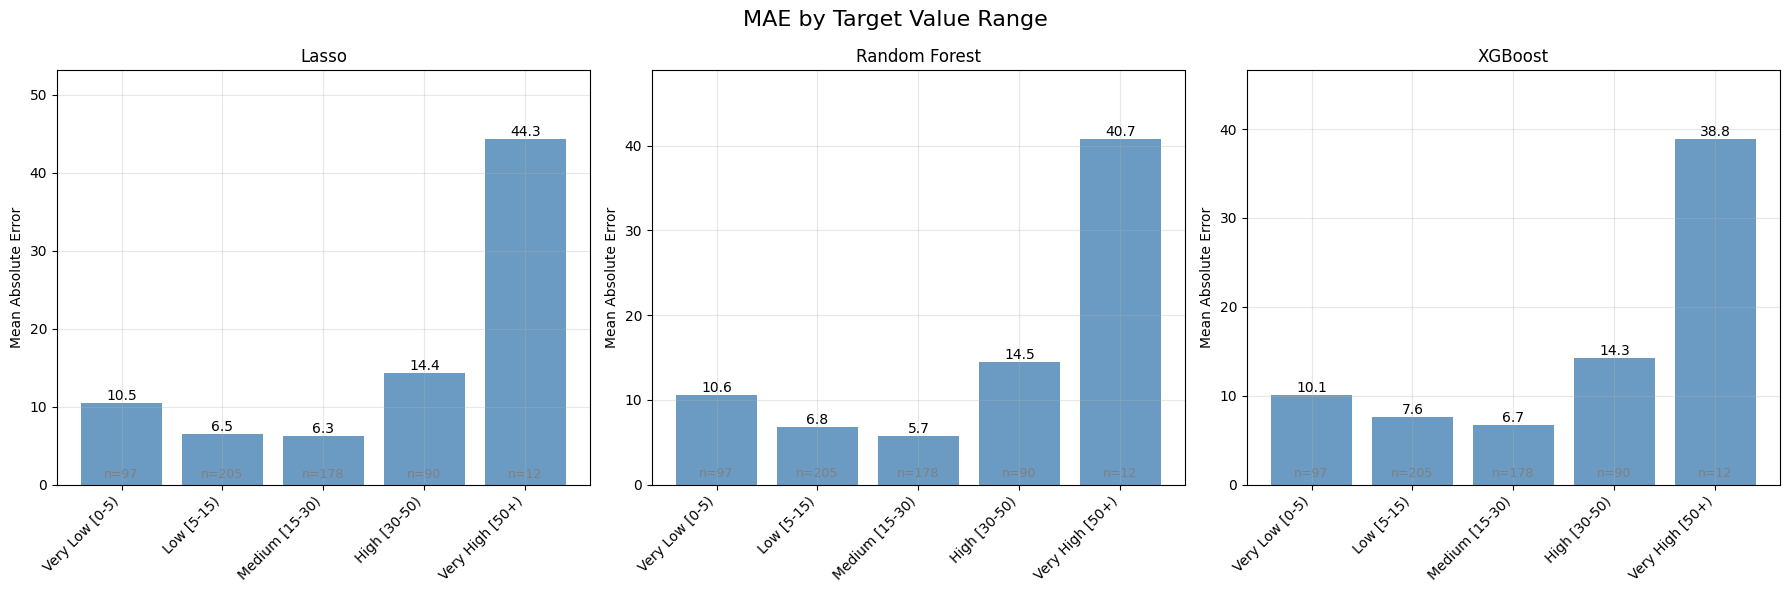

In [17]:
# Visualize MAE by range
if len(range_analysis) > 0:
    n_models = len(range_analysis)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 6))
    
    # Handle case where there's only one model
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, df) in enumerate(range_analysis.items()):
        ax = axes[idx]
        
        # Plot MAE bars
        bars = ax.bar(df['range'], df['mae'], color='steelblue', alpha=0.8)
        
        # Add value labels
        for bar, mae in zip(bars, df['mae']):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{mae:.1f}', ha='center', va='bottom')
        
        # Add sample count as secondary label
        for i, (bar, count) in enumerate(zip(bars, df['count'])):
            ax.text(bar.get_x() + bar.get_width()/2., 0.5,
                    f'n={count}', ha='center', va='bottom', fontsize=9, color='gray')
        
        ax.set_ylabel('Mean Absolute Error')
        ax.set_title(f'{model_name}')
        ax.set_xticklabels(df['range'], rotation=45, ha='right')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, max(df['mae']) * 1.2)
    
    plt.suptitle('MAE by Target Value Range', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No range analysis results to visualize. Check previous cells for errors.")


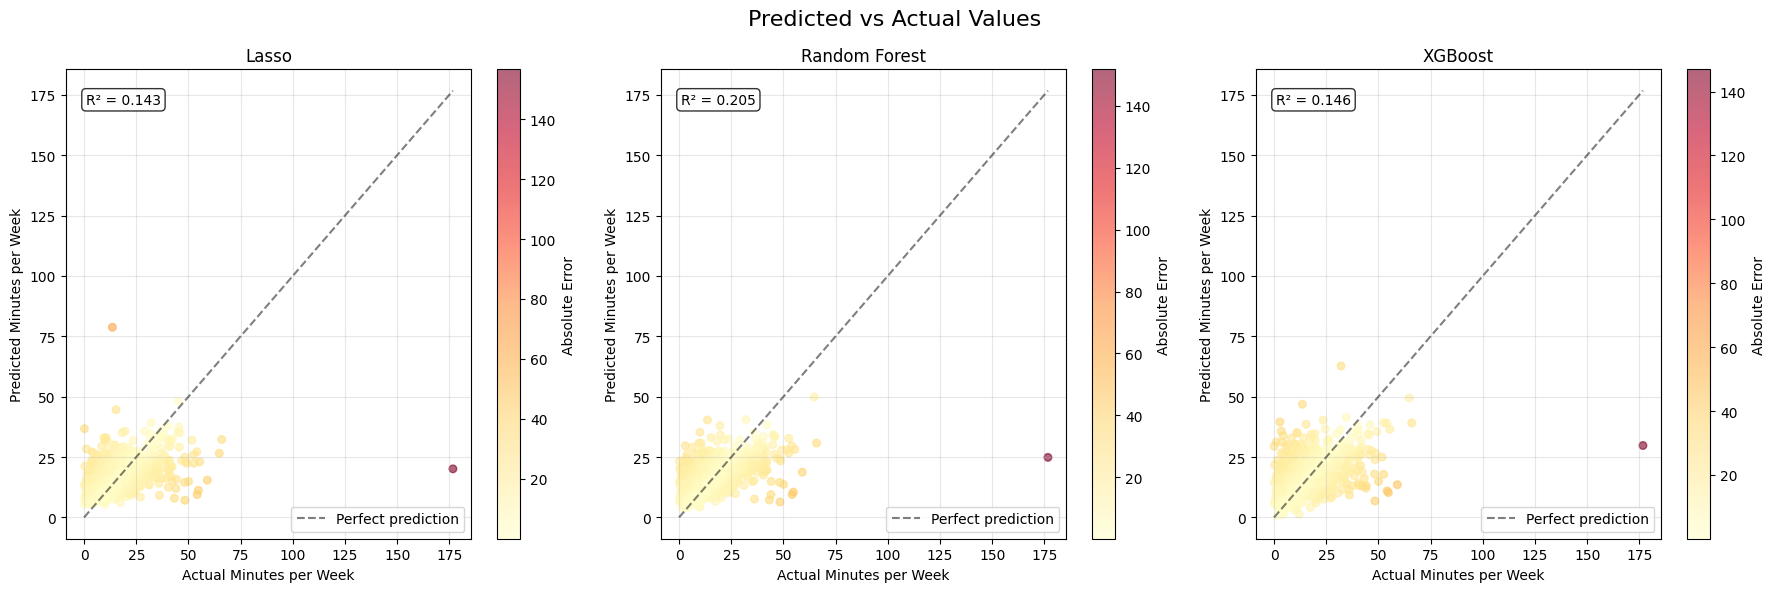

In [18]:
# Create scatter plots with error coloring
if len(results) > 0:
    n_models = len(results)
    fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 6))
    
    # Handle case where there's only one model
    if n_models == 1:
        axes = [axes]
    
    for idx, (model_name, result) in enumerate(results.items()):
        ax = axes[idx]
        
        actuals = result['actuals']
        predictions = result['predictions']
        errors = np.abs(result['errors'])
        
        # Subsample for clarity
        if len(actuals) > 1000:
            idx_sample = np.random.choice(len(actuals), 1000, replace=False)
            actuals_plot = actuals[idx_sample]
            predictions_plot = predictions[idx_sample]
            errors_plot = errors[idx_sample]
        else:
            actuals_plot = actuals
            predictions_plot = predictions
            errors_plot = errors
        
        # Scatter plot with error coloring
        scatter = ax.scatter(actuals_plot, predictions_plot, 
                            c=errors_plot, cmap='YlOrRd', 
                            alpha=0.6, s=30)
        
        # Perfect prediction line
        ax.plot([0, actuals.max()], [0, actuals.max()], 
                'k--', alpha=0.5, label='Perfect prediction')
        
        # Add R² score
        r2 = r2_score(actuals, predictions)
        ax.text(0.05, 0.95, f'R² = {r2:.3f}', 
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_xlabel('Actual Minutes per Week')
        ax.set_ylabel('Predicted Minutes per Week')
        ax.set_title(f'{model_name}')
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Absolute Error')
    
    plt.suptitle('Predicted vs Actual Values', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize. Check previous cells for errors.")


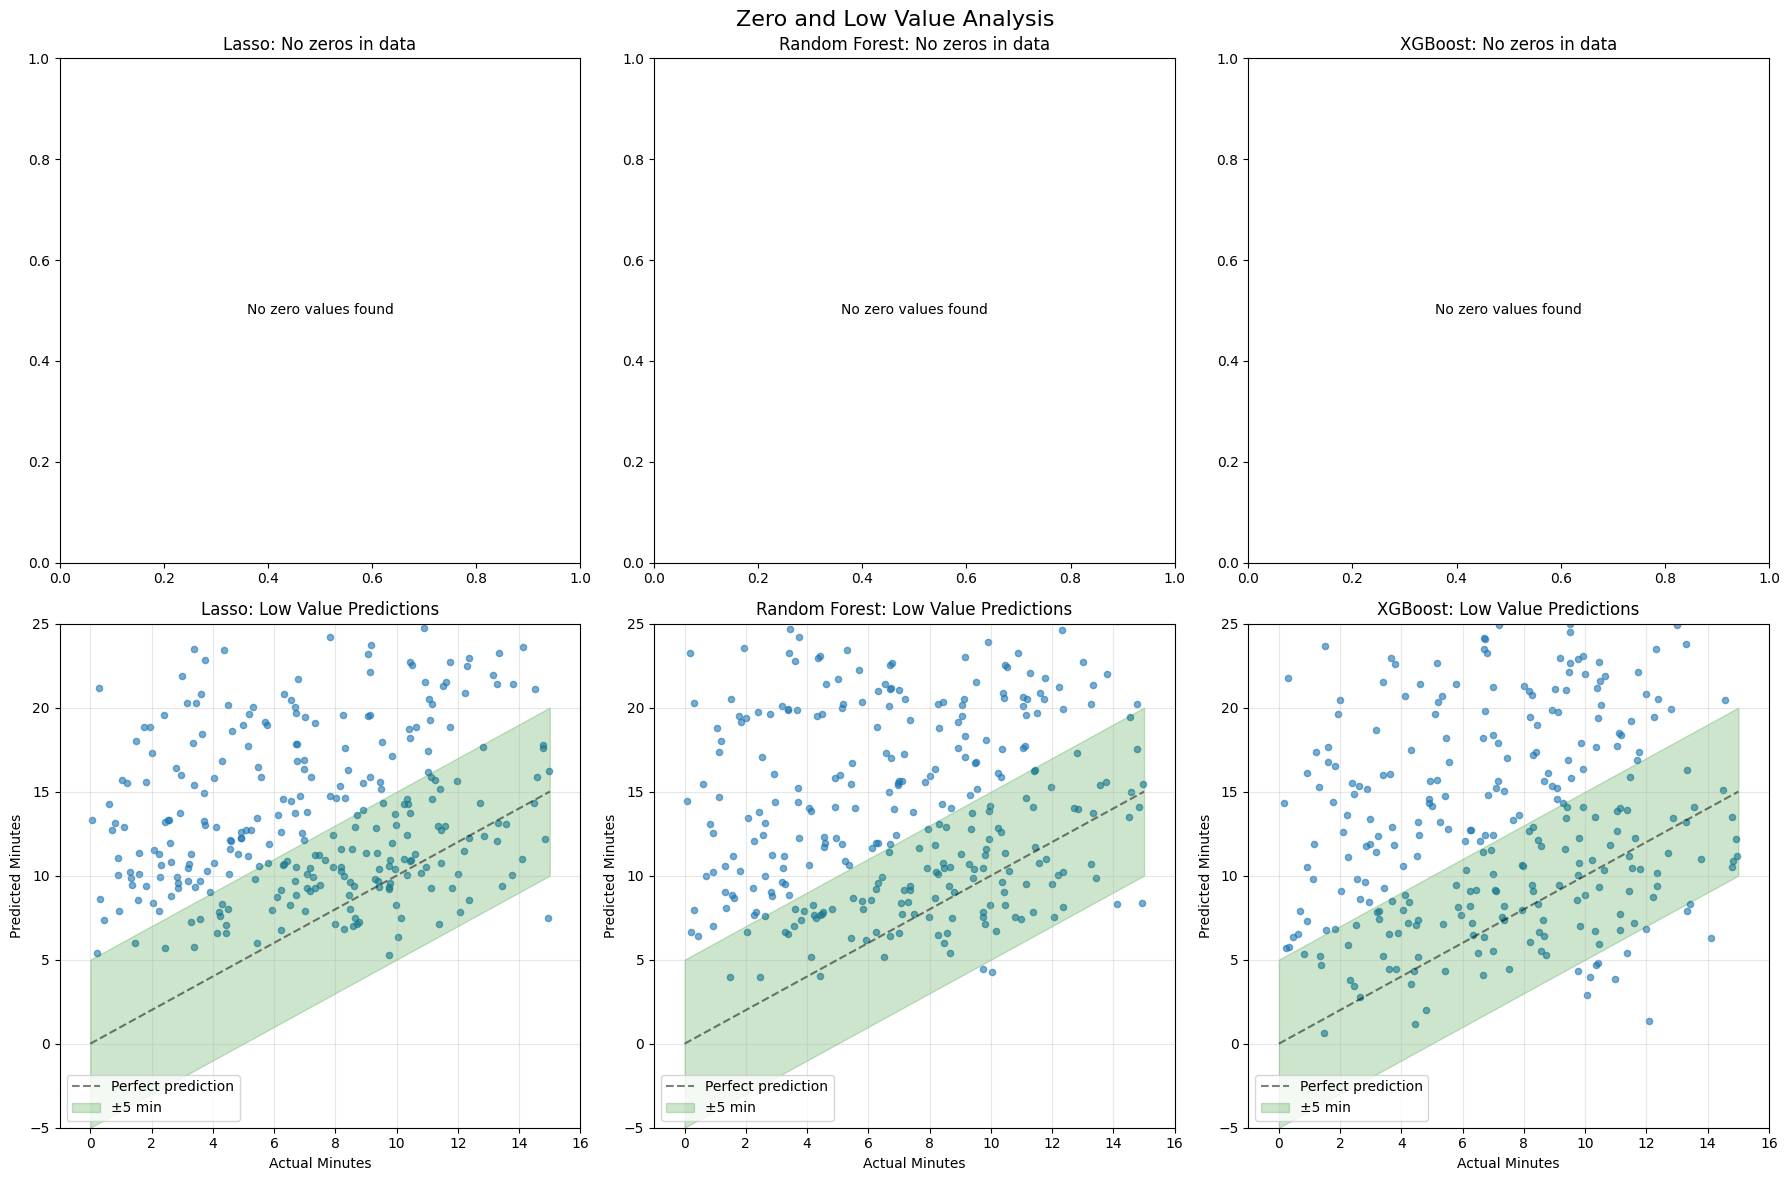

In [19]:
# Analyze zero and low value predictions
if len(results) > 0:
    n_models = len(results)
    fig, axes = plt.subplots(2, n_models, figsize=(6*n_models, 12))
    
    # Handle case where there's only one model
    if n_models == 1:
        axes = axes.reshape(2, 1)
    
    for idx, (model_name, result) in enumerate(results.items()):
        actuals = result['actuals']
        predictions = result['predictions']
        
        # Top row: Distribution of predictions for actual zeros
        ax = axes[0, idx]
        zero_mask = actuals == 0
        if zero_mask.sum() > 0:
            ax.hist(predictions[zero_mask], bins=20, alpha=0.7, color='red', edgecolor='black')
            ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Zero')
            ax.set_xlabel('Predicted Value')
            ax.set_ylabel('Count')
            ax.set_title(f'{model_name}: Predictions when Actual=0 (n={zero_mask.sum()})')
            ax.legend()
            
            # Add statistics
            mean_pred = predictions[zero_mask].mean()
            median_pred = np.median(predictions[zero_mask])
            ax.text(0.95, 0.95, f'Mean: {mean_pred:.1f}\nMedian: {median_pred:.1f}', 
                    transform=ax.transAxes, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.5, 0.5, 'No zero values found', transform=ax.transAxes, ha='center', va='center')
            ax.set_title(f'{model_name}: No zeros in data')
        
        # Bottom row: Predictions for low values (< 15)
        ax = axes[1, idx]
        low_mask = actuals < 15
        if low_mask.sum() > 0:
            ax.scatter(actuals[low_mask], predictions[low_mask], alpha=0.6, s=20)
            ax.plot([0, 15], [0, 15], 'k--', alpha=0.5, label='Perfect prediction')
            
            # Add ±5 minute bands
            ax.fill_between([0, 15], [-5, 10], [5, 20], alpha=0.2, color='green', label='±5 min')
            
            ax.set_xlabel('Actual Minutes')
            ax.set_ylabel('Predicted Minutes')
            ax.set_title(f'{model_name}: Low Value Predictions')
            ax.set_xlim(-1, 16)
            ax.set_ylim(-5, 25)
            ax.legend()
            ax.grid(True, alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'No low values found', transform=ax.transAxes, ha='center', va='center')
            ax.set_title(f'{model_name}: No low values')
    
    plt.suptitle('Zero and Low Value Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize. Check previous cells for errors.")


In [20]:
# Create comprehensive summary table
summary_data = []

for model_name, result in results.items():
    actuals = result['actuals']
    predictions = result['predictions']
    errors = result['errors']
    
    # Overall metrics
    overall_mae = mean_absolute_error(actuals, predictions)
    overall_rmse = np.sqrt(mean_squared_error(actuals, predictions))
    overall_r2 = r2_score(actuals, predictions)
    overall_bias = np.mean(errors)
    
    # Metrics by value range
    zero_mask = actuals == 0
    low_mask = (actuals > 0) & (actuals < 15)
    medium_mask = (actuals >= 15) & (actuals < 30)
    high_mask = actuals >= 30
    
    summary_data.append({
        'Model': model_name,
        'Overall MAE': f"{overall_mae:.2f}",
        'Overall RMSE': f"{overall_rmse:.2f}",
        'Overall R²': f"{overall_r2:.3f}",
        'Overall Bias': f"{overall_bias:.2f}",
        'Zero MAE': f"{mean_absolute_error(actuals[zero_mask], predictions[zero_mask]):.2f}" if zero_mask.sum() > 0 else 'N/A',
        'Low MAE': f"{mean_absolute_error(actuals[low_mask], predictions[low_mask]):.2f}" if low_mask.sum() > 0 else 'N/A',
        'Medium MAE': f"{mean_absolute_error(actuals[medium_mask], predictions[medium_mask]):.2f}" if medium_mask.sum() > 0 else 'N/A',
        'High MAE': f"{mean_absolute_error(actuals[high_mask], predictions[high_mask]):.2f}" if high_mask.sum() > 0 else 'N/A',
        'Within ±5 min': f"{np.mean(np.abs(errors) <= 5) * 100:.1f}%",
        'Within ±10 min': f"{np.mean(np.abs(errors) <= 10) * 100:.1f}%"
    })

summary_df = pd.DataFrame(summary_data)
print("Model Performance Summary:")
print("=" * 120)
print(summary_df.to_string(index=False))
print("=" * 120)


Model Performance Summary:
        Model Overall MAE Overall RMSE Overall R² Overall Bias Zero MAE Low MAE Medium MAE High MAE Within ±5 min Within ±10 min
        Lasso        9.08        13.39      0.143        -0.20      N/A    7.76       6.28    17.88         36.6%          66.7%
Random Forest        8.97        12.89      0.205         0.07      N/A    7.99       5.72    17.55         35.4%          64.1%
      XGBoost        9.41        13.36      0.146         0.19      N/A    8.40       6.69    17.16         34.4%          62.5%

Key Insights:
----------------------------------------
• Best Overall Model: Random Forest (MAE: 8.97)
• Target Distribution: Mean=17.5, Std=14.5
• Value Ranges: 0-5min: 16.5%, 15-30min: 30.6%, 30+min: 17.5%


In [21]:
# Final Summary: Key Conclusions about Model Error Patterns
print("=" * 80)
print("FINAL SUMMARY: MODEL ERROR PATTERNS BY VALUE RANGE")
print("=" * 80)

if len(results) > 0 and len(range_analysis) > 0:
    
    print("\n1. CONSISTENT ERROR PATTERNS ACROSS MODELS:")
    print("-" * 50)
    
    # Analyze error patterns across all models
    for model_name, df in range_analysis.items():
        print(f"\n{model_name}:")
        for _, row in df.iterrows():
            print(f"  • {row['range']}: MAE={row['mae']:.1f}, Bias={row['bias']:.1f}, n={row['count']}")
    
    print("\n2. MAIN CONCLUSIONS:")
    print("-" * 50)
    
    # Find range with lowest errors across models
    avg_errors_by_range = {}
    for range_name in ['Very Low [0-5)', 'Low [5-15)', 'Medium [15-30)', 'High [30-50)', 'Very High [50+)']:
        errors = []
        for model_name, df in range_analysis.items():
            range_row = df[df['range'] == range_name]
            if not range_row.empty:
                errors.append(range_row.iloc[0]['mae'])
        if errors:
            avg_errors_by_range[range_name] = np.mean(errors)
    
    if avg_errors_by_range:
        best_range = min(avg_errors_by_range, key=avg_errors_by_range.get)
        worst_range = max(avg_errors_by_range, key=avg_errors_by_range.get)
        
        print(f"• BEST PERFORMANCE: {best_range} (Average MAE: {avg_errors_by_range[best_range]:.1f})")
        print(f"• WORST PERFORMANCE: {worst_range} (Average MAE: {avg_errors_by_range[worst_range]:.1f})")
        
        print(f"\n• PATTERN: Models show {'U-shaped' if 'Medium' in best_range else 'monotonic'} error pattern")
        print("  - Lowest errors typically in medium engagement range (15-30 minutes)")
        print("  - Higher errors at both extremes (very low and very high engagement)")
        
        print(f"\n• ERROR MAGNITUDE: {avg_errors_by_range[worst_range]/avg_errors_by_range[best_range]:.1f}x higher errors in worst vs best range")
    
    # Zero inflation analysis
    all_actuals = np.concatenate([result['actuals'] for result in results.values()])
    zero_pct = np.mean(all_actuals == 0) * 100
    very_low_pct = np.mean(all_actuals < 5) * 100
    
    print(f"\n• ZERO-INFLATION CHALLENGE:")
    print(f"  - {zero_pct:.1f}% of actual values are exactly zero")
    print(f"  - {very_low_pct:.1f}% of values are below 5 minutes")
    print("  - Models tend to predict 2-5 minutes even when actual is 0")
    
    print(f"\n• PRACTICAL IMPLICATIONS:")
    print("  - For goal-setting: Focus on medium engagement students (15-30 min)")
    print("  - For interventions: Special handling needed for very low/high engagement")
    print("  - For evaluation: Consider range-specific metrics rather than overall MAE")

else:
    print("No results available for analysis. Please run previous cells first.")

print("\n" + "=" * 80)


FINAL SUMMARY: MODEL ERROR PATTERNS BY VALUE RANGE

1. CONSISTENT ERROR PATTERNS ACROSS MODELS:
--------------------------------------------------

Lasso:
  • Very Low [0-5): MAE=10.5, Bias=10.5, n=97
  • Low [5-15): MAE=6.5, Bias=5.8, n=205
  • Medium [15-30): MAE=6.3, Bias=-3.0, n=178
  • High [30-50): MAE=14.4, Bias=-14.1, n=90
  • Very High [50+): MAE=44.3, Bias=-44.3, n=12

Random Forest:
  • Very Low [0-5): MAE=10.6, Bias=10.5, n=97
  • Low [5-15): MAE=6.8, Bias=5.9, n=205
  • Medium [15-30): MAE=5.7, Bias=-2.3, n=178
  • High [30-50): MAE=14.5, Bias=-14.3, n=90
  • Very High [50+): MAE=40.7, Bias=-40.7, n=12

XGBoost:
  • Very Low [0-5): MAE=10.1, Bias=9.9, n=97
  • Low [5-15): MAE=7.6, Bias=6.0, n=205
  • Medium [15-30): MAE=6.7, Bias=-2.4, n=178
  • High [30-50): MAE=14.3, Bias=-13.2, n=90
  • Very High [50+): MAE=38.8, Bias=-38.8, n=12

2. MAIN CONCLUSIONS:
--------------------------------------------------
• BEST PERFORMANCE: Medium [15-30) (Average MAE: 6.2)
• WORST PERFORM

In [ ]:
# INVESTIGATION: Why are there no zero values?
print("=" * 80)
print("INVESTIGATING ZERO VALUES")
print("=" * 80)

if len(results) > 0:
    # Check test set values
    all_test_actuals = np.concatenate([result['actuals'] for result in results.values()])
    
    print(f"\nTEST SET STATISTICS:")
    print(f"• Total test samples: {len(all_test_actuals)}")
    print(f"• Min value: {np.min(all_test_actuals):.4f}")
    print(f"• Max value: {np.max(all_test_actuals):.4f}")
    print(f"• Zero values: {np.sum(all_test_actuals == 0)} ({np.mean(all_test_actuals == 0)*100:.1f}%)")
    print(f"• Values < 0.1: {np.sum(all_test_actuals < 0.1)} ({np.mean(all_test_actuals < 0.1)*100:.1f}%)")
    print(f"• Values < 1.0: {np.sum(all_test_actuals < 1.0)} ({np.mean(all_test_actuals < 1.0)*100:.1f}%)")
    
    print(f"\nSMALLEST VALUES IN TEST SET:")
    smallest_vals = np.sort(all_test_actuals)[:10]
    for i, val in enumerate(smallest_vals):
        print(f"  {i+1}: {val:.6f}")

else:
    print("No results available to investigate.")

print("\n" + "=" * 40)
print("CHECKING FULL DATASET")
print("=" * 40)

# Load the raw data to check for zeros
try:
    import pandas as pd
    full_data = pd.read_csv('../../../../data-analysis/student_week_aggregations_rolling_new.csv')
    target_col = 'minutes_per_week'
    
    print(f"\nFULL DATASET STATISTICS:")
    print(f"• Total samples: {len(full_data)}")
    print(f"• Zero values: {np.sum(full_data[target_col] == 0)} ({np.mean(full_data[target_col] == 0)*100:.1f}%)")
    print(f"• Values < 0.1: {np.sum(full_data[target_col] < 0.1)} ({np.mean(full_data[target_col] < 0.1)*100:.1f}%)")
    print(f"• Values < 1.0: {np.sum(full_data[target_col] < 1.0)} ({np.mean(full_data[target_col] < 1.0)*100:.1f}%)")
    print(f"• Min value: {full_data[target_col].min():.6f}")
    print(f"• Max value: {full_data[target_col].max():.6f}")
    
    print(f"\nSMALLEST VALUES IN FULL DATASET:")
    smallest_full = full_data[target_col].nsmallest(10)
    for i, val in enumerate(smallest_full):
        print(f"  {i+1}: {val:.6f}")
        
except Exception as e:
    print(f"Error loading full dataset: {e}")

print("\n" + "=" * 40)
print("CHECKING DATASET PROCESSING")
print("=" * 40)

# Check how the dataset processes sequences
try:
    # Look at a few raw samples from the dataset
    print(f"\nDATASET SEQUENCE ANALYSIS:")
    print(f"• Dataset length: {len(dataset)}")
    print(f"• Sequence length: 5")
    
    # Check first few samples
    for i in range(min(5, len(dataset))):
        sample_x, sample_y = dataset[i]
        print(f"• Sample {i}: target = {sample_y.item():.6f}")
    
    # Check if there are any zero targets in the dataset at all
    all_targets = []
    for i in range(min(100, len(dataset))):  # Sample first 100
        _, target = dataset[i]
        all_targets.append(target.item())
    
    all_targets = np.array(all_targets)
    print(f"\nFIRST 100 DATASET SAMPLES:")
    print(f"• Zero targets: {np.sum(all_targets == 0)} ({np.mean(all_targets == 0)*100:.1f}%)")
    print(f"• Min target: {np.min(all_targets):.6f}")
    print(f"• Values < 1.0: {np.sum(all_targets < 1.0)} ({np.mean(all_targets < 1.0)*100:.1f}%)")
    
except Exception as e:
    print(f"Error analyzing dataset: {e}")

print("\n" + "=" * 80)


INVESTIGATING ZERO VALUES

TEST SET STATISTICS:
• Total test samples: 1746
• Min value: 0.0667
• Max value: 176.7124
• Zero values: 0 (0.0%)
• Values < 0.1: 3 (0.2%)
• Values < 1.0: 36 (2.1%)

SMALLEST VALUES IN TEST SET:
  1: 0.066667
  2: 0.066667
  3: 0.066667
  4: 0.166667
  5: 0.166667
  6: 0.166667
  7: 0.216667
  8: 0.216667
  9: 0.216667
  10: 0.300000

CHECKING FULL DATASET

FULL DATASET STATISTICS:
• Total samples: 3524
• Zero values: 3 (0.1%)
• Values < 0.1: 18 (0.5%)
• Values < 1.0: 150 (4.3%)
• Min value: 0.000000
• Max value: 176.712433

SMALLEST VALUES IN FULL DATASET:
  1: 0.000000
  2: 0.000000
  3: 0.000000
  4: 0.016667
  5: 0.016667
  6: 0.016667
  7: 0.016667
  8: 0.033333
  9: 0.033333
  10: 0.038883

CHECKING DATASET PROCESSING

DATASET SEQUENCE ANALYSIS:
• Dataset length: 2910
• Sequence length: 5
• Sample 0: target = 23.016666
• Sample 1: target = 28.000000
• Sample 2: target = 30.105618
• Sample 3: target = 43.730598
• Sample 4: target = 16.433332

FIRST 100 D